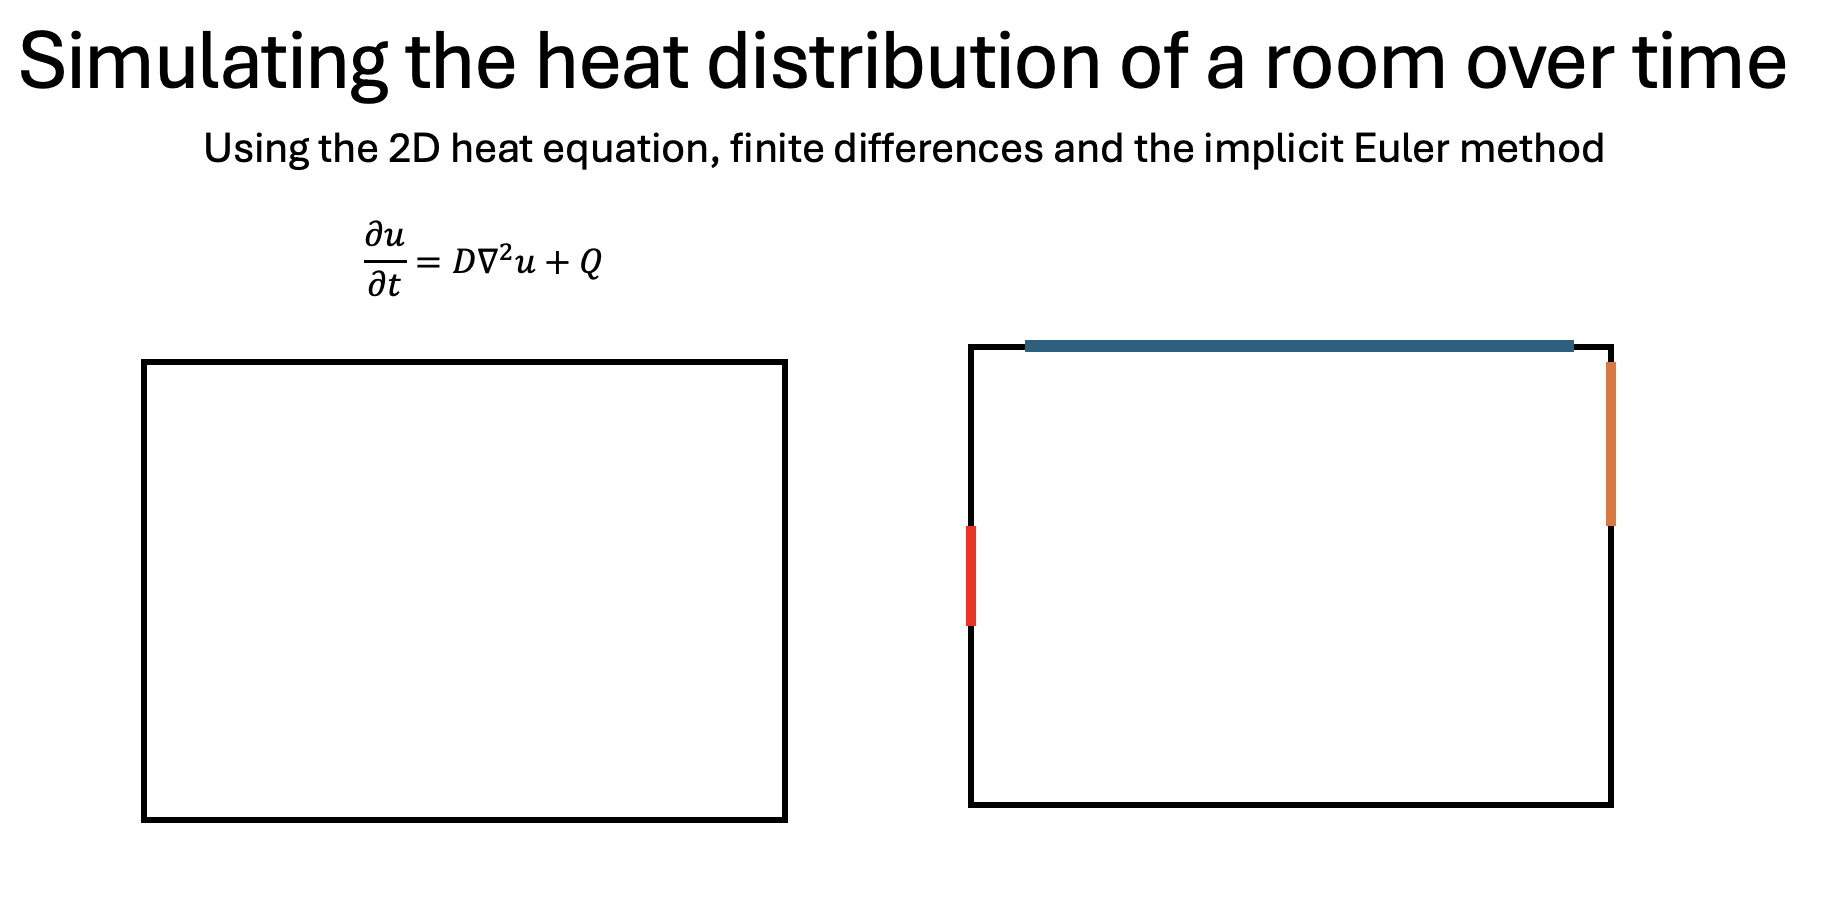

In [ ]:
## numerical solver for 2d time-dependent heat equation with neumann boundaries using implicit euler method

import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.animation as anim
import time

def construct_matrix(Nx, Ny, dx, dy, dt, D):
    A = np.zeros((Nx*Ny, Nx*Ny))

    rx = D * dt / dx**2
    ry = D * dt / dy**2
    A_const = 1 + 2 * (rx + ry)

    for j in range(0, Ny):
        for i in range(0, Nx):
            n = j*Nx + i

            A[n][n] = A_const

            if i == 0: #left
                A[n][n+1] = -2*rx

            elif i == Nx-1: #right
                A[n][n-1] = -2*rx

            else:
                A[n][n-1] = -rx
                A[n][n+1] = -rx
            
            if j == 0: #bottom
                A[n][n+Nx] = -2*ry

            elif j == Ny-1: #top
                A[n][n-Nx] = -2*ry
            
            else:
                A[n][n-Nx] = -ry
                A[n][n+Nx] = -ry
            
    return A

def construct_b(Nx, Ny, dx, dy, dt, D, g1, g2, g3, g4, t=0):
    b = np.zeros(Nx*Ny)
    n_idx = lambda i, j: j*Nx + i
    rx = D * dt / dx**2
    ry = D * dt / dy**2

    # bottom
    i = np.arange(0,Nx)
    j = 0
    n = n_idx(i,j)
    x, y = dx*i, dy*j
    b[n] += 4 * ry * dy * g4(x,y,t)

    # top
    i = np.arange(0,Nx)
    j = Ny-1
    n = n_idx(i,j)
    x, y = dx*i, dy*j
    b[n] += - 4 * ry * dy * g2(x,y,t)  *-1 ## I dont understand why we put -1 here

    # left
    i = 0
    j = np.arange(0,Ny)
    n = n_idx(i,j)
    x, y = dx*i, dy*j
    b[n] += 4 * rx * dx * g1(x,y,t)

    # right
    i = Nx-1
    j = np.arange(0,Ny)
    n = n_idx(i,j)
    x, y = dx*i, dy*j
    b[n] += -4 * rx * dx * g3(x,y,t) *-1 ## I dont understand why we put -1 here

    return b


In [ ]:
def RUN_SIMULATION(simulation_data, measure_heat_change=False): #only for non-time dependent g
    Lx, Ly, Nx, Ny, dx, dy, dt, D, g1, g2, g3, g4, max_time, u0 = simulation_data.values()
    Nx = int(Nx)
    Ny = int(Ny)
    X = np.linspace(0,Lx,Nx+1)
    Y = np.linspace(0,Ly,Ny+1)

    A = construct_matrix(Nx, Ny, dx, dy, dt, D)
    A_inv = np.linalg.inv(A)
    b = construct_b(Nx, Ny, dx, dy, dt, D, g1, g2, g3, g4)

    u = np.zeros([Ny, Nx]) + u0(X, Y)
    data = [u.copy()]

    max_iters = max_time / dt
    count = 0

    print(f"Running for {round(max_iters)} iterations")

    while count < max_iters+1:
        u = (A_inv @ (u.flatten() + b)).reshape(Ny, Nx)
        data.append(u)
        count += 1

    if measure_heat_change:
        heat_change = data[-1].sum() - data[0].sum()
        print(f"\nHeat change = {round(heat_change, 1)} ({round((heat_change/data[0].sum())*100, 1)})%\n")
    
    return data

def VISUALISE(data, Lx, Ly, Nx, Ny, max_time, dt, interval=20, save=True, savename="animate.mp4"):
    X = np.linspace(0,Lx,Nx+1)
    Y = np.linspace(0,Ly,Ny+1)
    max_iters = max_time / dt

    fig, axis = plt.subplots()
    pcm = axis.pcolormesh(X, Y, data[0], cmap=plt.cm.jet, vmin=min(0, np.array(data).min()), vmax=np.array(data).max())
    axis.set_aspect('equal')
    axis.set_xlabel('X (m)')
    axis.set_ylabel('Y (m)')
    axis.set_title('Heat distribution at t: 0.0 (s)')
    colorbar = plt.colorbar(pcm, ax=axis, shrink=0.6)
    colorbar.set_label('Temperature (°C)', rotation=270, labelpad=10)
    plt.close()

    def updateplot(idx):
        pcm.set_array(data[idx].flatten())
        axis.set_title("Heat distribution at t: {:.3f} (s)".format(idx*dt))
        return pcm

    plt.rcParams['animation.html'] = 'jshtml'
    animate = anim.FuncAnimation(fig=fig, func=updateplot, frames=int(max_iters), repeat=False, interval=interval) #ms
    
    if save:
        Writer = anim.writers['ffmpeg'] ## this won't run on LIS JupyterHub
        writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
        animate.save(savename, writer=writer)
        print(f"Saved to {savename}")
    
    return animate

In [ ]:
D = 2e-5 # diffusion constant for  air = 2e-5 (m^2 / s)

# dimensions of room in x- and y- directions (m)
Lx = 5
Ly = 3

# length of simulation (s)
max_time = 200

# grid spacing
dx = 0.1 # 10cm
dy = 0.1 # 10cm

# time step
dt = 0.005 # s

#dx = Lx/(Nx-1)
#dy = Ly/(Ny-1)
Nx = (Lx/dx)+1
Ny = (Ly/dy)+1

# initial room temperature (°C)
u0 = lambda x,y: 20

## BOUNDARY CONDITIONS

Ctop = -5 # constant for badly insulated wall
Cright = 0
Cbottom = 0

g2 = lambda x,y,t: Ctop*dt # top - heat loss from badly insulated wall
g3 = lambda x,y,t: Cright*dt # right - insulated wall
g4 = lambda x,y,t: Cbottom*dt # bottom - insulated wall

def g1(x,y,t): # left - includes log burner
    if not isinstance(y, np.ndarray):
        y = np.array(y)
    dxdt =  (dt*5e3) / (-0.025*0.25)    * -1   #35000 Q / -kA (conductivity of air; area=0.25)
    new_y = np.where((y > 1) & (y <= 2), dxdt, y)
    return new_y 

In [17]:
## set up simulation data

sim1 = {
    "Lx": Lx,
    "Ly": Ly,
    "Nx": int(Nx),
    "Ny": int(Ny),
    "dx": dx,
    "dy": dy,
    "dt": dt,
    "D": D,
    "g1": g1,
    "g2": g2,
    "g3": g3,
    "g4": g4,
    "max_time": max_time,
    "u0": u0
}

data = RUN_SIMULATION(sim1)
print("Simulation finished - saving")
VISUALISE(data, sim1["Lx"], sim1["Ly"], sim1["Nx"], sim1["Ny"], max_time, dt, interval=20)

Running for 40000 iterations
Simulation finished - saving


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '640x480', '-pix_fmt', 'rgba', '-framerate', '15', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '1800k', '-metadata', 'artist=Me', '-y', 'animate.mp4']' returned non-zero exit status 255.

In [26]:
VISUALISE(data[:int(len(data)/2)], sim1["Lx"], sim1["Ly"], sim1["Nx"], sim1["Ny"], int(max_time/2), dt, interval=1);

Saved to animate.mp4


 <video controls>
  <source src="animate1.mp4" type="video/mp4">
</video>